# Exploitation du graphe d'influences

In [44]:
from ipysigma import Sigma
import pickle
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from ipysigma import Sigma
import networkx as nx
import plotly.graph_objects as go
from ipysigma import Sigma
from networkx.algorithms import community as comm
from networkx.algorithms.community import label_propagation_communities
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.stats import entropy
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [52]:
with open("Q205519.pickle", "rb") as f:
    data = pickle.load(f)

In [46]:
def periode(str):
    try:
        date_deb = int(str[0:4])
        date_end = int(str[5:9])
        if date_deb is None :
            return "Unknown"
        elif date_deb < 1570 and date_deb > 476:
            return "Medieval"
        elif date_deb < 1730:
            return "Baroque"
        elif date_deb < 1800:
            return "Classique"
        elif date_deb < 1860:
            return "Romantique"
        else:
            try:
                date_end = int(date_end)
                return "XXe"
            except:
                return "contemporain"
    except :
        return "Unknown"

In [47]:
def dico_filenames(filename = "cross-era_annotations.csv"):
    dico = {}
    dico2 = {}
    df = pd.read_csv(filename, sep=',')
    for i in range(len(df)):
        dico[df['Filename'][i]] = df['Composer'][i]
        dico2[df['Filename'][i]] = periode(df['CompLifetime'][i])
    return dico, dico2
dico_composers, dico_periodes = dico_filenames()
a = np.array(list(dico_composers.values()))
np.unique(a)
# Imprime toutes les clés ayant pour valeur 'major'
for key, value in dico_composers.items():
    if value == ' major':
        print(key)
dico_composers["CrossEra-0616_Borodin_symphony_no.3_in_a_minor_moderato_assai.mp3"] = 'Borodin; Alexander'
dico_composers["CrossEra-0673_Liszt_poems__mazeppa.mp3"] = 'Liszt; Franz'
dico_composers["CrossEra-0674_Liszt_poems__prometheus.mp3"] = 'Liszt; Franz'
dico_composers["CrossEra-0776_Verdi_Overt_giovanna_darco_sinfonia.mp3"] = 'Verdi; Giuseppe'
dico_composers["CrossEra-1016_Cimarosa_Piano_sonata_no._24_in_b-flat_minor_major___andantino.mp3"] = 'Cimarosa; Domenico'

CrossEra-0616_Borodin_symphony_no.3_in_a_minor_moderato_assai.mp3
CrossEra-0673_Liszt_poems__mazeppa.mp3
CrossEra-0674_Liszt_poems__prometheus.mp3
CrossEra-0776_Verdi_Overt_giovanna_darco_sinfonia.mp3
CrossEra-1016_Cimarosa_Piano_sonata_no._24_in_b-flat_minor_major___andantino.mp3


In [48]:
# Load the data
with open("hist_cross-era.pkl", "rb") as f:
    dico_cross_era = pickle.load(f)

In [49]:
X = []
etiquettes = []
y = []
periode = []
for file, histograms in dico_cross_era.items():
    composer = dico_composers[file.split('/')[1]]
    etiquettes.append(file)
    matrice = np.vstack(histograms)
    X.append(matrice.flatten())
    y.append(composer)
    periode.append(dico_periodes[file.split('/')[1]])
X = np.array(X)
X_scaled = StandardScaler().fit_transform(X)
y = np.array(y)
periodes = np.array(periode)
morceaux = np.array(etiquettes)

In [9]:
dico_cross_era.keys()

dict_keys(['orchestra_addon/CrossEra-1602_Bach_CPE_sinfonia_in_b_flat_major_wq._182_no._2.mp3', 'orchestra_addon/CrossEra-1603_Bach_CPE_sinfonia_in_b_minor_wq._182_no._5.mp3', 'orchestra_addon/CrossEra-1604_Bach_CPE_sinfonia_in_c_major_wq._182_no._3.mp3', 'orchestra_addon/CrossEra-1605_Bach_CPE_sinfonia_in_e_major_wq._182_no._6.mp3', 'orchestra_addon/CrossEra-1606_Bach_CPE_sinfonia_in_g_major_wq._182_no._1.mp3', 'orchestra_addon/CrossEra-1607_Beethoven_egmont_overture_op.84.mp3', 'orchestra_addon/CrossEra-1608_beethoven_no002_01_adagio_molto__allegro_con_brio.mp3', 'orchestra_addon/CrossEra-1609_beethoven_no002_02_larghetto.mp3', 'orchestra_addon/CrossEra-1610_beethoven_no002_03_scherzo__allegro.mp3', 'orchestra_addon/CrossEra-1611_beethoven_no002_04_allegro_molto.mp3', 'orchestra_addon/CrossEra-1612_Beethoven_overt_consecration_of_the_house.mp3', 'orchestra_addon/CrossEra-1613_Beethoven_overt_coriolanus.mp3', 'orchestra_addon/CrossEra-1614_Beethoven_overt_creatures_of_prometheus.mp3',

In [7]:
print(f"Taille de X : {X.shape}"
      f"\nTaille de y : {y.shape}"
      f"\nNombre de classes : {len(np.unique(y))}"
      f"\nNombre d'instances : {len(y)}"
      f"\nNombre de features : {X.shape[1]}")

Taille de X : (1990, 4896)
Taille de y : (1990,)
Nombre de classes : 70
Nombre d'instances : 1990
Nombre de features : 4896


In [8]:
def dico_dates(filename = "cross-era_annotations.csv"):
    dico = {}
    df = pd.read_csv(filename, sep=',')
    for i in range(len(df)):
        dico[df['Composer'][i]] = df['CompLifetime'][i]
    return dico

In [9]:
dico_dates = dico_dates()
dico_dates

{'Albinoni; Tomaso': '1671-1751',
 'Bach; Johann Sebastian': '1685-1750',
 'Corelli; Arcangelo': '1653-1713',
 'Handel; George Frederic': '1685-1759',
 'Lully; Jean-Baptiste': '1632-1687',
 'Purcell; Henry': '1659-1695',
 'Rameau; Jean-Phillipe': '1683-1764',
 'Vivaldi; Antonio': '1678-1741',
 'Bach; Johann Christian': '1735-1782',
 'Boccherini; Luigi Rodolofo': '1743-1805',
 'Haydn; Johann Michael': '1737-1806',
 'Haydn; Joseph': '1732-1809',
 'Mozart; Wolfgang Amadeus': '1756-1791',
 'Pleyel; Ignace Joseph': '1757-1831',
 'Salieri; Antonio': '1750-1825',
 'Antheil; George': '1900-1959',
 'Bartok; Bela': '1881-1945',
 'Berg; Alban': '1885-1935',
 'Britten; Benjamin': '1913-1976',
 'Hindemith; Paul': '1895-1963',
 'Ives; Charles Edward': '1874-1954',
 'Messiaen; Olivier': '1908-1992',
 'Prokofiew; Sergej': '1891-1953',
 'Schoenberg; Arnold': '1874-1951',
 'Shostakovich; Dmitri': '1906-1975',
 'Stravinsky; Igor': '1882-1971',
 'Varese; Edgar': '1883-1965',
 'Webern; Anton': '1883-1945',

In [10]:
def get_dates(comp):
    try:
        date_naiss = int(comp[:4])
        try:
            date_deces = int(comp[5:9])
        except:
            date_deces = None
        return date_naiss, date_deces
    except:
        return None, None

In [11]:
def compare_compositeurs(comp1,comp2, dico = dico_dates):
    date_naiss1, date_deces1 = get_dates(dico[comp1])
    date_naiss2, date_deces2 = get_dates(dico[comp2])
    # print(f"Comparaison entre {comp1} et {comp2}")
    # print(f"Dates de naissance : {date_naiss1} - {date_naiss2}")
    # print(f"Dates de décès : {date_deces1} - {date_deces2}")
    
    li_influ = []
    
    if date_naiss1 is None or date_naiss2 is None:
        return li_influ
    
    if date_deces1 is None :
        date_deces1 = 2025
    if date_deces2 is None :
        date_deces2 = 2025
    
    if date_naiss1 > date_deces2 - 20:
        li_influ.append((comp2,comp1))
    
    if date_naiss2 > date_deces1 - 20:
        li_influ.append((comp1,comp2))
    
    if li_influ==[]:
        li_influ.append((comp1,comp2))
        li_influ.append((comp2,comp1))

    return li_influ

## Test de la meilleure dimension


🔍 Dimension LDA : 1

🔍 Dimension LDA : 3

🔍 Dimension LDA : 5

🔍 Dimension LDA : 7

🔍 Dimension LDA : 9

🔍 Dimension LDA : 11

🔍 Dimension LDA : 13

🔍 Dimension LDA : 15

🔍 Dimension LDA : 17

🔍 Dimension LDA : 19

🔍 Dimension LDA : 21

🔍 Dimension LDA : 23

🔍 Dimension LDA : 25

🔍 Dimension LDA : 27

🔍 Dimension LDA : 29

🔍 Dimension LDA : 31

🔍 Dimension LDA : 33

🔍 Dimension LDA : 35

🔍 Dimension LDA : 37

🔍 Dimension LDA : 39

🔍 Dimension LDA : 41

🔍 Dimension LDA : 43

🔍 Dimension LDA : 45

🔍 Dimension LDA : 47

🔍 Dimension LDA : 49

🔍 Dimension LDA : 51

🔍 Dimension LDA : 53

🔍 Dimension LDA : 55

🔍 Dimension LDA : 57

🔍 Dimension LDA : 59

🔍 Dimension LDA : 61

🔍 Dimension LDA : 63

🔍 Dimension LDA : 65

🔍 Dimension LDA : 67

🔍 Dimension LDA : 69

✅ Meilleure dimension LDA : 9 (entropie moyenne = 2.4963)

Détail des scores par dimension LDA :
Dimension =  1 → Entropie moyenne = 2.6289
Dimension =  3 → Entropie moyenne = 2.5639
Dimension =  5 → Entropie moyenne = 2.5110
Dimensio

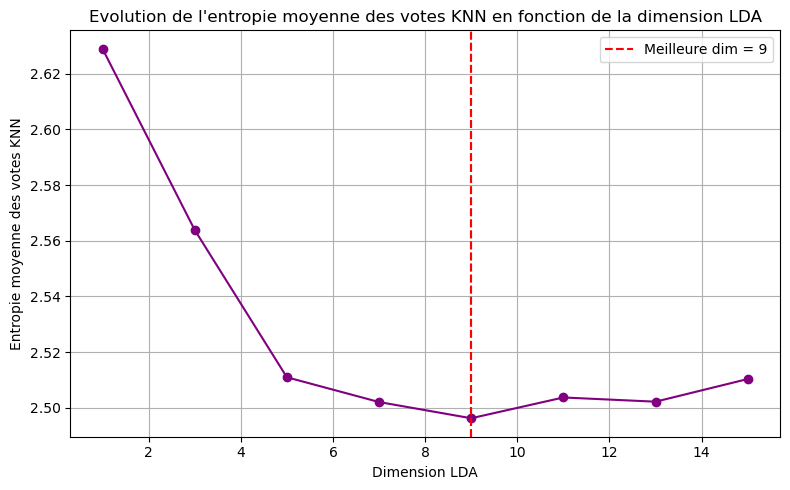

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# -------------------------------
# 2. Encodage de y (texte → int)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
n_classes = len(class_names)
max_lda_dim = n_classes - 1
#max_lda_dim = 4

# -------------------------------
# 3. Paramètres
n_neighbors = 7
n_splits = 5
pca_dim = 500
random_state = 42
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

pca = PCA(n_components=pca_dim, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)


# -------------------------------
# 4. Fonction de score : entropie moyenne des votes de voisins
def neighbor_entropy(X_proj, y_labels, n_neighbors, class_count):
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1)  # +1 pour ignorer le point lui-même
    nn.fit(X_proj)
    distances, indices = nn.kneighbors(X_proj)
    
    neighbor_idxs = indices[:, 1:]
    neighbor_votes = y_labels[neighbor_idxs]  # shape (n_samples, n_neighbors)
    
    probs = np.zeros((X_proj.shape[0], class_count))
    for i in range(X_proj.shape[0]):
        for cls in range(class_count):
            probs[i, cls] = np.mean(neighbor_votes[i] == cls)
    
    entropies = entropy(probs.T + 1e-12, base=2)  # T pour (n_classes, n_samples)
    return np.mean(entropies)

# -------------------------------
# 5. Boucle sur les dimensions LDA
scores_by_dim = []

for dim in range(1, max_lda_dim+1,2):
    try:
        print(f"\n🔍 Dimension LDA : {dim}")
        fold_entropies = []

        for train_idx, test_idx in skf.split(X, y_encoded):
            X_train, X_test = X_pca[train_idx], X_pca[test_idx]
            y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

            lda = LinearDiscriminantAnalysis(n_components=dim, solver='eigen', shrinkage='auto')
            X_train_lda = lda.fit_transform(X_train, y_train)
            X_test_lda = lda.transform(X_test)

            # Calcul de l'entropie sur les points test (votes de leurs 4 voisins dans l'espace projeté)
            fold_entropy = neighbor_entropy(X_test_lda, y_test, n_neighbors, n_classes)
            fold_entropies.append(fold_entropy)

        mean_entropy = np.mean(fold_entropies)
        scores_by_dim.append((dim, mean_entropy))
    except:
        continue


# -------------------------------
# 6. Résultat
best_dim, best_entropy = min(scores_by_dim, key=lambda x: x[1])
print(f"\n✅ Meilleure dimension LDA : {best_dim} (entropie moyenne = {best_entropy:.4f})")

print("\nDétail des scores par dimension LDA :")
for dim, ent in scores_by_dim:
    print(f"Dimension = {dim:2d} → Entropie moyenne = {ent:.4f}")

# -------------------------------
# 7. Visualisation
dims, entropies = zip(*scores_by_dim)
plt.figure(figsize=(8, 5))
plt.plot(dims, entropies, marker='o', color='purple')
plt.axvline(best_dim, color='red', linestyle='--', label=f"Meilleure dim = {best_dim}")
plt.xlabel('Dimension LDA')
plt.ylabel('Entropie moyenne des votes KNN')
plt.title("Evolution de l'entropie moyenne des votes KNN en fonction de la dimension LDA")
plt.axvline(best_dim, color='red', linestyle='--')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Extraction des centroïdes

In [76]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
n_classes = len(class_names)
lda_dim = 9
n_neighbors = 4
n_splits = 5
pca_dim = 100
random_state = 42
pca = PCA(n_components=pca_dim, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)
lda = LinearDiscriminantAnalysis(n_components=lda_dim, solver='eigen', shrinkage='auto')
X_lda = lda.fit_transform(X_pca, y_encoded)
dico_centroids = {}
for cls in range(n_classes):
    composer = class_names[cls]
    class_points = X_lda[y_encoded == cls]
    centroid = class_points.mean(axis=0)
    dico_centroids[composer] = centroid

# Calcul de la matrice des distances euclidiennes entre centroïdes
centroid_matrix = np.vstack([dico_centroids[composer] for composer in class_names])
distance_matrix = pairwise_distances(centroid_matrix, metric='euclidean')


fig = go.Figure(data=go.Heatmap(
    z=distance_matrix,
    x=class_names,
    y=class_names,
    colorscale='Reds',
    colorbar=dict(title='Distance euclidienne'),
    hovertemplate='De %{y}<br>à %{x}<br>Distance: %{z:.2f}<extra></extra>',
))

fig.update_layout(
    title="Matrice des distances entre compositeurs (centroïdes LDA)",
    xaxis=dict(tickangle=90, tickfont=dict(size=8)),
    yaxis=dict(tickfont=dict(size=8)),
    width=900,
    height=800,
    margin=dict(l=100, b=100, t=50, r=50)
)
fig.show()

In [77]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
n_classes = len(class_names)
lda_dim = 3
n_neighbors = 4
n_splits = 5
pca_dim = 100
random_state = 42
pca = PCA(n_components=pca_dim, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)
lda = LinearDiscriminantAnalysis(n_components=lda_dim, solver='eigen', shrinkage='auto')
X_lda = lda.fit_transform(X_pca, y_encoded)
dico_centroids = {}
dico_classes = {}
for cls in range(n_classes):
    composer = class_names[cls]
    dico_classes[cls] = composer
    class_points = X_lda[y_encoded == cls]
    centroid = class_points.mean(axis=0)
    dico_centroids[composer] = centroid

# Calcul de la matrice des distances euclidiennes entre centroïdes
centroid_matrix = np.vstack([dico_centroids[composer] for composer in class_names])
distance_matrix = pairwise_distances(centroid_matrix, metric='euclidean')


fig = go.Figure(data=go.Heatmap(
    z=distance_matrix,
    x=class_names,
    y=class_names,
    colorscale='Viridis',
    colorbar=dict(title='Distance euclidienne'),
    hovertemplate='De %{y}<br>à %{x}<br>Distance: %{z:.2f}<extra></extra>',
))

fig.update_layout(
    title="Matrice des distances entre compositeurs (centroïdes LDA)",
    xaxis=dict(tickangle=90, tickfont=dict(size=8)),
    yaxis=dict(tickfont=dict(size=8)),
    width=900,
    height=800,
    margin=dict(l=100, b=100, t=50, r=50)
)
fig.show()

centroids_3d = np.vstack([dico_centroids[composer][:3] for composer in class_names])
fig_3d = go.Figure(data=[go.Scatter3d(
    x=centroids_3d[:, 0],
    y=centroids_3d[:, 1],
    z=centroids_3d[:, 2],
    mode='markers',
    marker=dict(size=7, color='royalblue', opacity=0.8),
    text=class_names,
    hovertemplate='<b>%{text}</b><br>x: %{x:.2f}<br>y: %{y:.2f}<br>z: %{z:.2f}<extra></extra>',
    showlegend=False
)])
fig_3d.update_layout(
    title="Centroïdes des compositeurs dans l'espace LDA (3D)",
    scene=dict(
        xaxis_title='LDA 1',
        yaxis_title='LDA 2',
        zaxis_title='LDA 3'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)
fig_3d.show()

## Génération du graphe

In [78]:
seuil = 0.65
G = nx.DiGraph()
for composer, centroid in dico_centroids.items():
    G.add_node(composer, pos=centroid[:3])
for comp1 in dico_centroids:
    for comp2 in dico_centroids:
        if comp1 != comp2:
            dist = np.linalg.norm(dico_centroids[comp1][:3] - dico_centroids[comp2][:3])
            if dist < seuil:
                influ = compare_compositeurs(comp1, comp2, dico=dico_dates)
                for comp1_influ, comp2_influ in influ:
                    if not G.has_edge(comp1_influ, comp2_influ):
                        G.add_edge(comp1, comp2, weight=seuil - dist)

In [83]:
import math

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
cmap = matplotlib.cm.get_cmap('coolwarm')

# Normaliser les poids pour la colormap
weights = np.array([d['weight'] for _, _, d in G.edges(data=True)])
w_min, w_max = weights.min(), weights.max()

for u, v, d in G.edges(data=True):
    norm_weight = (d['weight'] - w_min) / (w_max - w_min) if w_max > w_min else 0.5
    rgba = cmap(norm_weight)
    # Convertir en couleur hexadécimale
    d['color_edge'] = matplotlib.colors.rgb2hex(rgba)

layout = {}
grid_positions = {}

angle_step = 2 * math.pi / max(1,len(G.nodes()))
radius = 1
for i,node in enumerate(G.nodes()):
    angle = i * angle_step
    layout[node] = {
        "x": radius * math.cos(angle),
        "y": radius * math.sin(angle)
    }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = nx.pagerank(G)

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_5976\4256180328.py:5: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



Sigma(nx.DiGraph with 70 nodes and 314 edges)

In [23]:
compare_compositeurs("Beethoven; Ludwig van","Verdi; Giuseppe", dico=dico_dates)

[('Beethoven; Ludwig van', 'Verdi; Giuseppe')]

In [24]:
G.has_edge("Beethoven; Ludwig van", "Verdi; Giuseppe")

True

In [25]:
G.has_edge("Verdi; Giuseppe","Beethoven; Ludwig van")

False

## Test de Louvain

In [84]:
import math

communautés = nx.algorithms.community.louvain_communities(G)
for i, commu in enumerate(communautés):
    for node in commu:
        G.nodes[node]['communauté'] = i

with open(f"graph_euclidian_seuil={seuil}_communautés.pickle", "wb") as f:
    pickle.dump(G, f)

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
import numpy as np
from IPython.display import Markdown
cmap = matplotlib.cm.get_cmap('coolwarm')
# Générer une couleur différente pour chaque communauté
import matplotlib.colors as mcolors

# Utiliser la meilleure partition trouvée précédemment
num_communities = len(communautés)
colors = list(mcolors.TABLEAU_COLORS.values())
if num_communities > len(colors):
    # Générer plus de couleurs si besoin
    cmap_communities = matplotlib.cm.get_cmap('tab20', num_communities)
    colors = [matplotlib.colors.rgb2hex(cmap_communities(i)) for i in range(num_communities)]

for node in G.nodes():
    G.nodes[node]['color'] = colors[G.nodes[node]['communauté']]

# Calculer la disposition des communautés en cercles
layout = {}
radius_outer = 3
radius_inner = 0.4
angle_step_outer = 2 * np.pi / num_communities

for idx, community in enumerate(communautés):
    angle_center = idx * angle_step_outer
    cx = radius_outer * np.cos(angle_center)
    cy = radius_outer * np.sin(angle_center)
    n_nodes = len(community)
    angle_step_inner = 2 * np.pi / max(n_nodes, 1)
    for j, node in enumerate(community):
        angle = j * angle_step_inner
        layout[node] = {
            "x": cx + radius_inner * np.cos(angle),
            "y": cy + radius_inner * np.sin(angle)
        }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = G.out_degree(weight='weight')

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)

display(Markdown("## Graphe des influences entre compositeurs (seuil={}) avec {} communautés".format(seuil, len(communautés))))

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_5976\2966935436.py:15: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_5976\2966935436.py:24: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



## Graphe des influences entre compositeurs (seuil=0.65) avec 17 communautés

Sigma(nx.DiGraph with 70 nodes and 314 edges)

## Calcul de communautés

Nombre de communautés : 9
Nombre de communautés : 10
Nombre de communautés : 11
Nombre de communautés : 12
Nombre de communautés : 13
Nombre de communautés : 14
Nombre de communautés : 15
Nombre de communautés : 16
Nombre de communautés : 17
Nombre de communautés : 18
Nombre de communautés : 19
Nombre de communautés : 20
Nombre de communautés : 21
Nombre de communautés : 22
Nombre de communautés : 23
Nombre de communautés : 24
Nombre de communautés : 25
Nombre de communautés : 26
Nombre de communautés : 27
Nombre de communautés : 28
Nombre de communautés : 29
Nombre de communautés : 30
Nombre de communautés : 31
Nombre de communautés : 32
Nombre de communautés : 33
Nombre de communautés : 34
Nombre de communautés : 35
Nombre de communautés : 36
Nombre de communautés : 37
Nombre de communautés : 38
Nombre de communautés : 39
Nombre de communautés : 40
Nombre de communautés : 41
Nombre de communautés : 42
Nombre de communautés : 43
Nombre de communautés : 44
Nombre de communautés : 45
No

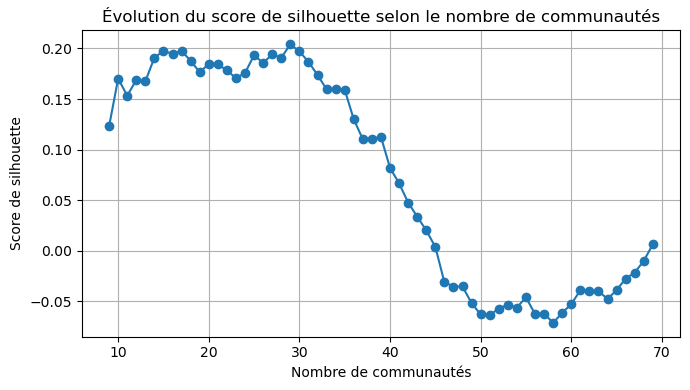

Meilleur score silhouette : 0.2042
Nombre de communautés : 29


In [27]:
from networkx.algorithms.community.centrality import girvan_newman
from networkx import edge_betweenness_centrality as betweenness
from sklearn.metrics import silhouette_score
def most_central_edge(G):
    centrality = betweenness(G, weight="weight")
    return max(centrality, key=centrality.get)
partition = nx.community.girvan_newman(G, most_valuable_edge=most_central_edge)
# Générer les partitions (limité à k=2 à 10 communautés pour éviter trop de calculs)
silhouette_scores = []
partition_lengths = []
best_score = -1
best_partition = None
for communities in partition:
    n_communities = len(communities)
    partition_lengths.append(n_communities)
    print(f"Nombre de communautés : {n_communities}")
    labels = np.zeros(len(G.nodes()), dtype=int)
    for idx, community in enumerate(communities):
        for node in community:
            labels[list(G.nodes()).index(node)] = idx
    # Calcul du score silhouette sur les centroïdes (distance_matrix)
    score = silhouette_score(distance_matrix, labels, metric='precomputed')
    silhouette_scores.append(score)
    if score > best_score or n_communities == 22:
        best_score = score
        best_partition = communities
    if n_communities >= 69:
        break

# Tracer l'évolution du score de silhouette
plt.figure(figsize=(7, 4))
plt.plot(partition_lengths, silhouette_scores, marker='o')
plt.xlabel("Nombre de communautés")
plt.ylabel("Score de silhouette")
plt.title("Évolution du score de silhouette selon le nombre de communautés")
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Meilleur score silhouette : {best_score:.4f}")
print(f"Nombre de communautés : {len(best_partition)}")

In [32]:
import math


import matplotlib
import numpy as np
cmap = matplotlib.cm.get_cmap('coolwarm')
import matplotlib.colors as mcolors

# Utiliser la meilleure partition trouvée précédemment
communities = best_partition
num_communities = len(communities)
colors = list(mcolors.TABLEAU_COLORS.values())
if num_communities > len(colors):
    # Générer plus de couleurs si besoin
    cmap_communities = matplotlib.cm.get_cmap('tab20', num_communities)
    colors = [matplotlib.colors.rgb2hex(cmap_communities(i)) for i in range(num_communities)]

# Attribuer une couleur à chaque noeud selon sa communauté
node_community_color = {}
for idx, community in enumerate(communities):
    for node in community:
        node_community_color[node] = colors[idx]

for node in G.nodes():
    G.nodes[node]['color'] = node_community_color[node]


layout = {}
radius_outer = 1.5
radius_inner = 0.4
angle_step_outer = 2 * np.pi / num_communities

for idx, community in enumerate(communities):
    angle_center = idx * angle_step_outer
    cx = radius_outer * np.cos(angle_center)
    cy = radius_outer * np.sin(angle_center)
    n_nodes = len(community)
    angle_step_inner = 2 * np.pi / max(n_nodes, 1)
    for j, node in enumerate(community):
        angle = j * angle_step_inner
        layout[node] = {
            "x": cx + radius_inner * np.cos(angle),
            "y": cy + radius_inner * np.sin(angle)
        }


# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=G.out_degree()
)
sigma

/var/folders/6_/wjb9ddn965xckzzthm1x7rnr0000gn/T/ipykernel_22945/762436875.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

/var/folders/6_/wjb9ddn965xckzzthm1x7rnr0000gn/T/ipykernel_22945/762436875.py:15: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



Sigma(nx.DiGraph with 70 nodes and 314 edges)

In [29]:
import math

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
import numpy as np
cmap = matplotlib.cm.get_cmap('coolwarm')
# Générer une couleur différente pour chaque communauté
import matplotlib.colors as mcolors

# Utiliser la meilleure partition trouvée précédemment
communities = label_propagation_communities(G)
num_communities = len(communities)
colors = list(mcolors.TABLEAU_COLORS.values())
if num_communities > len(colors):
    # Générer plus de couleurs si besoin
    cmap_communities = matplotlib.cm.get_cmap('tab20', num_communities)
    colors = [matplotlib.colors.rgb2hex(cmap_communities(i)) for i in range(num_communities)]

# Attribuer une couleur à chaque noeud selon sa communauté
node_community_color = {}
for idx, community in enumerate(communities):
    for node in community:
        node_community_color[node] = colors[idx]

# Ajouter la couleur au graphe
for node in G.nodes():
    G.nodes[node]['color'] = node_community_color[node]

# Calculer la disposition des communautés en cercles
layout = {}
radius_outer = 1.5
radius_inner = 0.4
angle_step_outer = 2 * np.pi / num_communities

for idx, community in enumerate(communities):
    angle_center = idx * angle_step_outer
    cx = radius_outer * np.cos(angle_center)
    cy = radius_outer * np.sin(angle_center)
    n_nodes = len(community)
    angle_step_inner = 2 * np.pi / max(n_nodes, 1)
    for j, node in enumerate(community):
        angle = j * angle_step_inner
        layout[node] = {
            "x": cx + radius_inner * np.cos(angle),
            "y": cy + radius_inner * np.sin(angle)
        }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = nx.pagerank(G)

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

/var/folders/6_/wjb9ddn965xckzzthm1x7rnr0000gn/T/ipykernel_22945/795474530.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



NetworkXNotImplemented: not implemented for directed type

## Génération d'une autre distance

In [31]:
import ot
from scipy.spatial.distance import cdist
def distance(cls1,cls2,X,y):
    """Calcul de la distance de Wasserstein entre deux distributions de probabilité."""
    # On suppose que cls1 et cls2 sont les labels (valeurs de y) des deux classes à comparer
    # X : matrice des features, y : labels associés (déjà présents dans le notebook)

    # Sélectionner les vecteurs de chaque classe
    X1 = X[y == cls1]
    X2 = X[y == cls2]

    d_xy = cdist(X1, X2, metric='euclidean')
    term_xy = 2 * np.mean(d_xy)

    # Termes intra-classes : E[||x - x'||]
    d_xx = cdist(X1, X1, metric='euclidean')
    term_xx = np.mean(d_xx)

    d_yy = cdist(X2, X2, metric='euclidean')
    term_yy = np.mean(d_yy)

    # Energy distance
    return np.sqrt(term_xy - term_xx - term_yy)

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
n_classes = len(class_names)
lda_dim = 3
n_neighbors = 4
n_splits = 5
pca_dim = 100
random_state = 42
pca = PCA(n_components=pca_dim, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)
lda = LinearDiscriminantAnalysis(n_components=lda_dim, solver='eigen', shrinkage='auto')
X_lda = lda.fit_transform(X_pca, y_encoded)
dico_centroids = {}
for cls in range(n_classes):
    composer = class_names[cls]
    class_points = X_lda[y_encoded == cls]
    centroid = class_points.mean(axis=0)
    dico_centroids[composer] = centroid

# Calcul de la matrice des distances euclidiennes entre centroïdes
centroid_matrix = np.vstack([dico_centroids[composer] for composer in class_names])
distance_matrix = np.zeros((n_classes, n_classes))
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j:
            distance_matrix[i, j] = distance(i, j,X,y_encoded)


fig = go.Figure(data=go.Heatmap(
    z=distance_matrix,
    x=class_names,
    y=class_names,
    colorscale='Viridis',
    colorbar=dict(title='Distance de Wasserstein'),
    hovertemplate='De %{y}<br>à %{x}<br>Distance: %{z:.2f}<extra></extra>',
))

fig.update_layout(
    title="Matrice des distances entre compositeurs (centroïdes LDA)",
    xaxis=dict(tickangle=90, tickfont=dict(size=8)),
    yaxis=dict(tickfont=dict(size=8)),
    width=900,
    height=800,
    margin=dict(l=100, b=100, t=50, r=50)
)
fig.show()

In [ ]:
compare_compositeurs("Mozart; Wolfgang Amadeus","Beethoven; Ludwig van")

In [38]:
G = nx.DiGraph()
seuil = 1.3
for value,item in dico_classes.items():
    G.add_node(item, pos=centroid[:3])
for comp1 in range(len(class_names)):
    for comp2 in range(len(class_names)):
        if comp1 != comp2:
            dist = distance_matrix[comp1, comp2]
            if dist < seuil:
                composer1, composer2 = class_names[comp1], class_names[comp2]
                influences = compare_compositeurs(composer1, composer2, dico_dates)
                for c in influences :
                    if not G.has_edge(c[0], c[1]):
                        G.add_edge(c[0], c[1], weight=seuil-dist)

pickle.dump(G, open(f"graphe_oriente_centroids_pot_seuil={seuil}.pkl", "wb"))

In [42]:
import math


import matplotlib
cmap = matplotlib.cm.get_cmap('viridis')

weights = np.array([d['weight'] for _, _, d in G.edges(data=True)])
w_min, w_max = weights.min(), weights.max()

for u, v, d in G.edges(data=True):
    norm_weight = (d['weight'] - w_min) / (w_max - w_min) if w_max > w_min else 0.5
    rgba = cmap(norm_weight)
    # Convertir en couleur hexadécimale
    d['color_edge'] = matplotlib.colors.rgb2hex(rgba)

layout = {}
grid_positions = {}

angle_step = 2 * math.pi / max(1,len(G.nodes()))
radius = 1
for i,node in enumerate(G.nodes()):
    angle = i * angle_step
    layout[node] = {
        "x": radius * math.cos(angle),
        "y": radius * math.sin(angle)
    }


# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=G.out_degree(),  
)


sigma

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_5976\2072085314.py:5: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



Sigma(nx.DiGraph with 70 nodes and 521 edges)

In [ ]:
from networkx.algorithms.community.centrality import girvan_newman
from networkx import edge_betweenness_centrality as betweenness
from sklearn.metrics import silhouette_score
def most_central_edge(G):
    centrality = betweenness(G, weight="weight")
    return max(centrality, key=centrality.get)
partition = nx.community.girvan_newman(G, most_valuable_edge=most_central_edge)
# Générer les partitions (limité à k=2 à 10 communautés pour éviter trop de calculs)
silhouette_scores = []
partition_lengths = []
best_score = -1
best_partition = None
no_enregistres = [26,39]
partitions_enregistreees = []
for communities in partition:
    n_communities = len(communities)
    partition_lengths.append(n_communities)
    print(f"Nombre de communautés : {n_communities}")
    labels = np.zeros(len(G.nodes()), dtype=int)
    for idx, community in enumerate(communities):
        for node in community:
            labels[list(G.nodes()).index(node)] = idx
    # Calcul du score silhouette sur les centroïdes (distance_matrix)
    score = silhouette_score(distance_matrix, labels, metric='precomputed')
    silhouette_scores.append(score)
    if n_communities in no_enregistres:
        partitions_enregistreees.append(communities)
        print(f"Enregistrement de la partition avec {n_communities} communautés")
    if score > best_score or n_communities == 30:
        best_score = score
        best_partition = communities
    if n_communities >= 36:
        break

# Tracer l'évolution du score de silhouette
plt.figure(figsize=(7, 4))
plt.plot(partition_lengths, silhouette_scores, marker='o')
plt.xlabel("Nombre de communautés")
plt.ylabel("Score de silhouette")
plt.title("Évolution du score de silhouette selon le nombre de communautés")
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Meilleur score silhouette : {best_score:.4f}")
print(f"Nombre de communautés : {len(best_partition)}")

In [ ]:
import math

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
import numpy as np
from IPython.display import Markdown
cmap = matplotlib.cm.get_cmap('coolwarm')
# Générer une couleur différente pour chaque communauté
import matplotlib.colors as mcolors

# Utiliser la meilleure partition trouvée précédemment
communities = partitions_enregistreees[0] #or best_partition
num_communities = len(communities)
colors = list(mcolors.TABLEAU_COLORS.values())
if num_communities > len(colors):
    # Générer plus de couleurs si besoin
    cmap_communities = matplotlib.cm.get_cmap('tab20', num_communities)
    colors = [matplotlib.colors.rgb2hex(cmap_communities(i)) for i in range(num_communities)]

# Attribuer une couleur à chaque noeud selon sa communauté
node_community_color = {}
for idx, community in enumerate(communities):
    for node in community:
        node_community_color[node] = colors[idx]

# Ajouter la couleur au graphe
for node in G.nodes():
    G.nodes[node]['color'] = node_community_color[node]

# Calculer la disposition des communautés en cercles
layout = {}
radius_outer = 3
radius_inner = 0.4
angle_step_outer = 2 * np.pi / num_communities

for idx, community in enumerate(communities):
    angle_center = idx * angle_step_outer
    cx = radius_outer * np.cos(angle_center)
    cy = radius_outer * np.sin(angle_center)
    n_nodes = len(community)
    angle_step_inner = 2 * np.pi / max(n_nodes, 1)
    for j, node in enumerate(community):
        angle = j * angle_step_inner
        layout[node] = {
            "x": cx + radius_inner * np.cos(angle),
            "y": cy + radius_inner * np.sin(angle)
        }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = G.out_degree(weight='weight')

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)

display(Markdown("## Graphe des influences entre compositeurs (seuil={}) avec {} communautés".format(seuil, len(communities))))

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

### Test de Louvain

In [50]:
import math

communautés = nx.algorithms.community.louvain_communities(G)
for i, commu in enumerate(communautés):
    for node in commu:
        G.nodes[node]['communauté'] = i

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
import numpy as np
from IPython.display import Markdown
cmap = matplotlib.cm.get_cmap('coolwarm')
# Générer une couleur différente pour chaque communauté
import matplotlib.colors as mcolors

# Utiliser la meilleure partition trouvée précédemment
num_communities = len(communautés)
colors = list(mcolors.TABLEAU_COLORS.values())
if num_communities > len(colors):
    # Générer plus de couleurs si besoin
    cmap_communities = matplotlib.cm.get_cmap('tab20', num_communities)
    colors = [matplotlib.colors.rgb2hex(cmap_communities(i)) for i in range(num_communities)]

for node in G.nodes():
    G.nodes[node]['color'] = colors[G.nodes[node]['communauté']]

# Calculer la disposition des communautés en cercles
layout = {}
radius_outer = 3
radius_inner = 0.4
angle_step_outer = 2 * np.pi / num_communities

for idx, community in enumerate(communautés):
    angle_center = idx * angle_step_outer
    cx = radius_outer * np.cos(angle_center)
    cy = radius_outer * np.sin(angle_center)
    n_nodes = len(community)
    angle_step_inner = 2 * np.pi / max(n_nodes, 1)
    for j, node in enumerate(community):
        angle = j * angle_step_inner
        layout[node] = {
            "x": cx + radius_inner * np.cos(angle),
            "y": cy + radius_inner * np.sin(angle)
        }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = G.out_degree(weight='weight')

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)

display(Markdown("## Graphe des influences entre compositeurs (seuil={}) avec {} communautés".format(seuil, len(communautés))))

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_5976\106240148.py:12: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_5976\106240148.py:21: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



## Graphe des influences entre compositeurs (seuil=1.3) avec 22 communautés

Sigma(nx.DiGraph with 70 nodes and 521 edges)

### Test de Louvain pour le graphe de données

In [69]:
def prepare_sigma_with_composer_ids(original_graph):
    """Relabels a graph using Composer.id as node labels and returns a Sigma widget. The new sigma compatible graph is named graph and returned by the function"""
    #id_map = {node: int(node.id.replace('Q','')) for node in original_graph.nodes()}
    id_map={node: str(node)+" - "+str(node.id) for node in original_graph.nodes()}
    graph = nx.relabel_nodes(original_graph, id_map)
    #for node in original_graph.nodes(data=True) :
    #    print("og",node)

    # Clean all node/edge attributes to make sure they're JSON serializable because the composer object was not accepted by ipysigma
    for n, d in graph.nodes(data=True):
        #print(n,d)
        for k, v in d.items():
            if not isinstance(v, (str, int, float, bool, type(None))):
                d[k] = str(v)
    
    for n in original_graph.nodes():
        graph.nodes[str(n)+" - "+str(n.id)]['source']=n.description
        graph.nodes[str(n)+" - "+str(n.id)]['periode']=n.get_era()

    for u, v, d in graph.edges(data=True):
        for k, val in d.items():
            if not isinstance(val, (str, int, float, bool, type(None))):
                d[k] = str(val)

    layout = {
        node: {
            "x": math.cos(i * 2 * math.pi / len(graph)),
            "y": math.sin(i * 2 * math.pi / len(graph)),
        }
        for i, node in enumerate(graph)
    }

    #pagerank_scores = nx.pagerank(graph)

    #for k, v in pagerank_scores.items():
    #    assert isinstance(v, (int, float)), f"Non-numeric pagerank for node {k}: {v}"
    #for u, v, d in g.edges(data=True):
    for u, v, d in graph.edges(data=True):
        if d.get("source") == "chroma":
            #graph[str(u)+" - "+str(u.id)][str(v)+" - "+str(v.id)]["color_edge"] = "#3498DB"  # Blue for chroma
            #graph[str(u)+" - "+str(u.id)][str(v)+" - "+str(v.id)]["source"]="chroma"
            graph[u][v]["color_edge"] = "#3498DB"  # Blue for chroma
            graph[u][v]["source"]="chroma"
        elif d.get("source") == "chroma and influ":
            graph[u][v]["color_edge"] ="#2ECC71"
            graph[u][v]["source"]="chroma and influ" #Green for influ and chroma (the edge was present in both graphs)
        else:
            graph[u][v]["color_edge"] = "#E74C3C"  # Red for only influ (or default)
            graph[u][v]["source"]="influ"

    sigma = Sigma(
        graph=graph,
        layout=layout,
        default_edge_type="curve",
        node_border_color_from="node",
        raw_edge_color="color_edge",
        label_font="cursive",
        node_size=graph.out_degree()#pagerank_scores
    )

    return graph,sigma

In [72]:
with open("Q174606.pickle", "rb") as f:
    G = pickle.load(f)

G, sigma = prepare_sigma_with_composer_ids(G)
sigma

Sigma(nx.DiGraph with 1,889 nodes and 4,888 edges)

In [73]:
import math

communautés = nx.algorithms.community.louvain_communities(G)
for i, commu in enumerate(communautés):
    for node in commu:
        G.nodes[node]['communauté'] = i

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
import numpy as np
from IPython.display import Markdown
cmap = matplotlib.cm.get_cmap('coolwarm')
# Générer une couleur différente pour chaque communauté
import matplotlib.colors as mcolors

# Utiliser la meilleure partition trouvée précédemment
num_communities = len(communautés)
colors = list(mcolors.TABLEAU_COLORS.values())
if num_communities > len(colors):
    # Générer plus de couleurs si besoin
    cmap_communities = matplotlib.cm.get_cmap('tab20', num_communities)
    colors = [matplotlib.colors.rgb2hex(cmap_communities(i)) for i in range(num_communities)]

for node in G.nodes():
    G.nodes[node]['color'] = colors[G.nodes[node]['communauté']]

partitions = {"Medieval":[],"Baroque":[], "Classique":[], "Romantique":[], "XXe":[], "contemporain":[],"Unknown":[]}

for node in G.nodes:
    era = G.nodes[node]['periode']  # Default to "medium"
    #graph.nodes[str(node)+" - "+str(node.id)]["color_node"] = color.get(era, "#95A5A6")  # Gray if unknown
    #g.nodes[node]["size"] = 10  # Set a default size
    #partitions[era].append(graph.nodes[str(node)+" - "+str(node.id)])
    partitions[era].append(node)


for source, target in G.edges:
    G.edges[source, target]["color_edge"] = G.nodes[target]["color"]

layout = {}

# Grid positions for each era cluster center
grid_positions = {
    "Medieval": (0, 0),
    "Baroque": (-3, 0),
    "Classique": (0, 2),
    "Romantique": (3, 0),
    "XXe": (-2, -2),
    "contemporain": (2, -2)
}

# Assign circular layouts within each cluster
for era, node_names in partitions.items():
    base_x, base_y = grid_positions.get(era, (0, 0))
    angle_step = 2 * np.pi / max(1, len(node_names))
    radius = 1.5  # Distance from center of cluster

    for i, node_name in enumerate(node_names):
        angle = i * angle_step
        layout[node_name] = {
            "x": base_x + radius * np.cos(angle),
            "y": base_y + radius * np.sin(angle)
        }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = G.out_degree(weight='weight')

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)

display(Markdown("## Graphe des influences entre compositeurs (seuil={}) avec {} communautés".format(seuil, len(communautés))))

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_5976\2147834356.py:12: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

C:\Users\PCAJM\AppData\Local\Temp\ipykernel_5976\2147834356.py:21: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



## Graphe des influences entre compositeurs (seuil=1.3) avec 14 communautés

Sigma(nx.DiGraph with 1,889 nodes and 4,888 edges)